# 10x Visium 空間トランスクリプトーム解析 / Spatial Transcriptomics with 10x Visium

10x Genomics Visium データの読み込み・QC・正規化・クラスタリング・空間可視化までの基本フローをたどる。
解析ロジックは `src/` のモジュールに置き、このノートブックからは import して呼ぶだけにとどめる（方針は [CLAUDE.md](../CLAUDE.md) を参照）。

Walks through the basic flow for 10x Genomics Visium data: loading, QC, normalization, clustering, and spatial visualization.
The analysis logic lives in modules under `src/`; this notebook only imports and calls them (see [CLAUDE.md](../CLAUDE.md) for the rationale).


## 1. 環境・パス設定 / Environment and Paths


In [19]:
import os
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc


In [20]:
# プロジェクトルートを自動判定する（リポジトリ直下／notebooks/ のどちらから起動しても動く）
# Resolve the project root automatically (works whether launched from the repo root or notebooks/)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [ ]:
from config import load_config, get_paths
from src.preprocessing import (
    read_visium_sample,
    add_qc_metrics,
    filter_cells_and_genes,
    normalize_and_hvg,
)
from src.clustering import (
    DimReduceParams,
    ClusteringParams,
    run_dimensionality_reduction,
    run_clustering,
    build_spatial_neighbors,
    run_moran_i,
)
from src.visualization import plot_qc_violin, plot_umap, plot_spatial


In [22]:
# 表示設定 / Display settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")


In [23]:
# パス設定 / Paths
paths = get_paths(PROJECT_ROOT)
paths


{'project_root': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics'),
 'data_raw': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics/data/raw'),
 'data_processed': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics/data/processed'),
 'results': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics/results'),
 'notebooks': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics/notebooks'),
 'scripts': PosixPath('/Users/kie/projects/03_self-study/spatial-transcriptomics/scripts')}

In [24]:
# config.yaml から設定を読み込む / Load settings from config.yaml
cfg = load_config(PROJECT_ROOT)
pprint(cfg)


{'clustering': {'method': 'leiden', 'resolution': 1.0},
 'dimension_reduction': {'neighbors_k': 15,
                         'pca_n_components': 50,
                         'umap_min_dist': 0.5},
 'export': {'dpi': 150,
            'run_name': 'run',
            'save_anndata': True,
            'save_plots': True},
 'feature_selection': {'method': 'hvg', 'n_top_genes': 2000},
 'inputs': {'sample_id': 'breast_cancer',
            'spaceranger_out_dir': '',
            'tissue_image_path': ''},
 'markers': {'method': 'wilcoxon', 'n_genes': 50},
 'normalization': {'method': 'log1p', 'target_sum': 10000},
 'project': {'description': '',
             'name': 'spatial-transcriptomics',
             'random_seed': 0},
 'qc': {'min_cells': 5, 'min_genes_per_spot': 500, 'pct_counts_mt_max': 12}}


In [25]:
# sample_id をサンプルのディレクトリパスに変換する / Resolve sample_id to its directory
sample_path = paths["data_raw"] / cfg["inputs"]["sample_id"]
print(sample_path)


/Users/kie/projects/03_self-study/spatial-transcriptomics/data/raw/breast_cancer


## 2. Visium データの読み込み / Loading Visium Data


In [26]:
# H5 と spatial/ を含むディレクトリから読み込む。ファイル探索は src 側に置く
# Load from a directory containing the H5 file and spatial/; file lookup lives in src
adata = read_visium_sample(sample_path)
print(adata.shape)


reading /Users/kie/projects/03_self-study/spatial-transcriptomics/data/raw/breast_cancer/Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5
 (0:00:00)
(4898, 36601)


/Users/kie/projects/03_self-study/spatial-transcriptomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/kie/projects/03_self-study/spatial-transcriptomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [27]:
print(adata.shape)          # 行列サイズ
print(adata.obs.head())     # 細胞/スポット情報
print(adata.var.head())     # 遺伝子情報


(4898, 36601)
                    in_tissue  array_row  array_col
AAACAACGAATAGTTC-1          1          0         16
AAACAAGTATCTCCCA-1          1         50        102
AAACAATCTACTAGCA-1          1          3         43
AAACACCAATAACTGC-1          1         59         19
AAACAGAGCGACTCCT-1          1         14         94
                    gene_ids    feature_types  genome
MIR1302-2HG  ENSG00000243485  Gene Expression  GRCh38
FAM138A      ENSG00000237613  Gene Expression  GRCh38
OR4F5        ENSG00000186092  Gene Expression  GRCh38
AL627309.1   ENSG00000238009  Gene Expression  GRCh38
AL627309.3   ENSG00000239945  Gene Expression  GRCh38


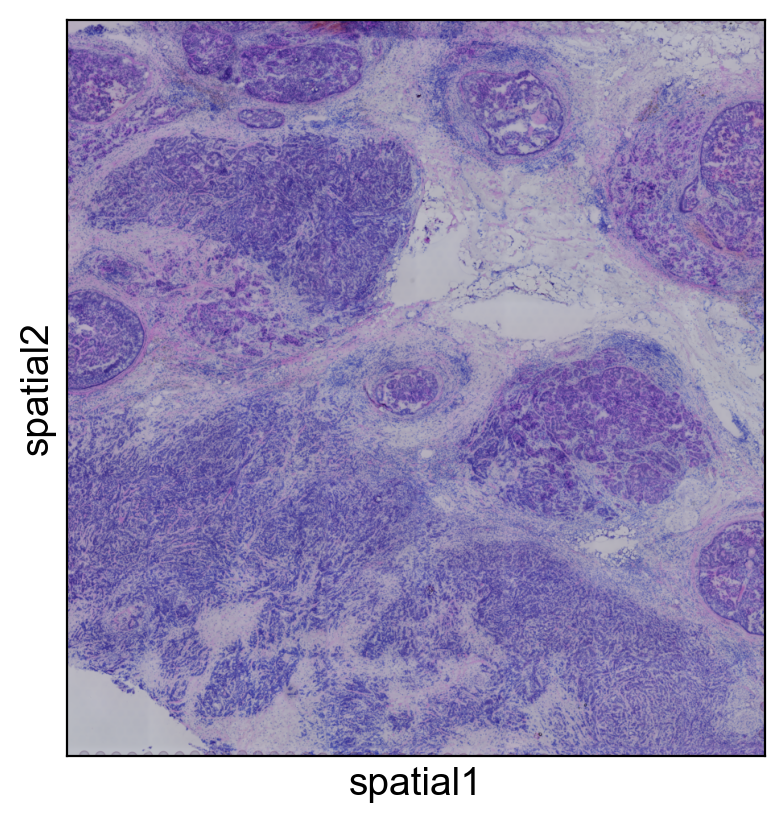

In [28]:
# 組織像とスポットの配置を確認する / Check tissue image and spot layout
plot_spatial(adata, color=None)


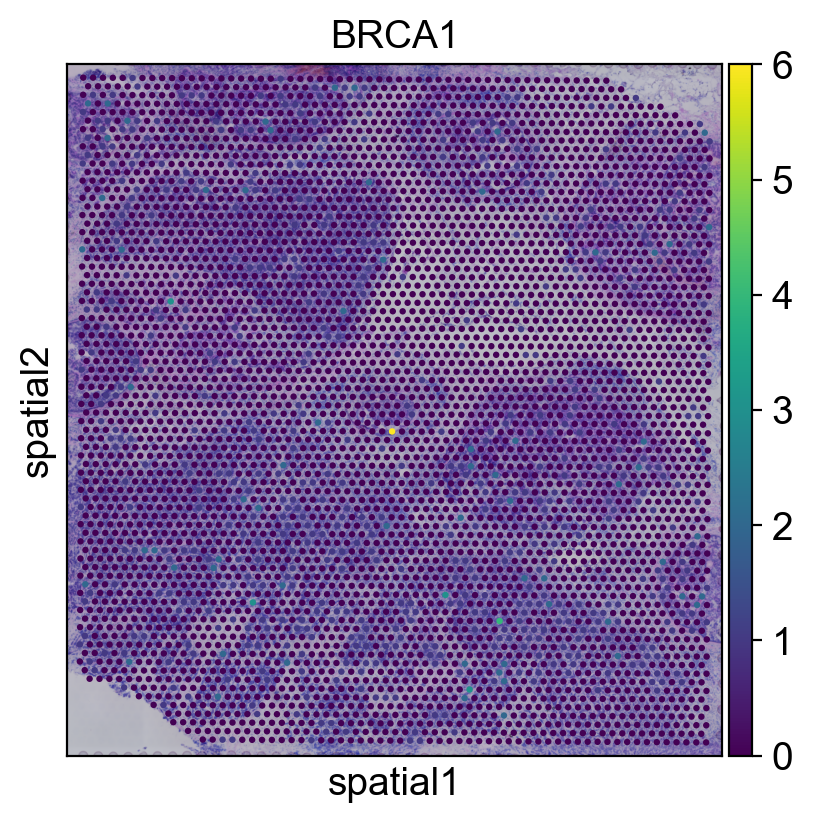

In [29]:
# 任意の遺伝子の空間発現を見る / Spatial expression of a gene of interest
plot_spatial(adata, color="BRCA1")


## 3. QC とフィルタリング / QC and Filtering

フィルタ前後で QC 指標の分布を確認する。閾値は `config/config.yaml` の `qc` セクションで管理する。

| 指標 | 意味 |
| --- | --- |
| `n_genes_by_counts` | スポットごとに検出された遺伝子の種類数 |
| `total_counts` | スポットごとの UMI 総数。PCR 重複を除去した後の分子数 |
| `pct_counts_mt` | ミトコンドリア遺伝子由来 UMI の割合。細胞が壊れると mRNA が漏出して上がるため、高い側が品質低下のサイン |

violin は横幅がスポットの密度、点が個々のスポットを表す。

Inspect the distribution of QC metrics before and after filtering. Thresholds are managed in the `qc` section of `config/config.yaml`.
In the violin plots, width encodes spot density and each dot is one spot.


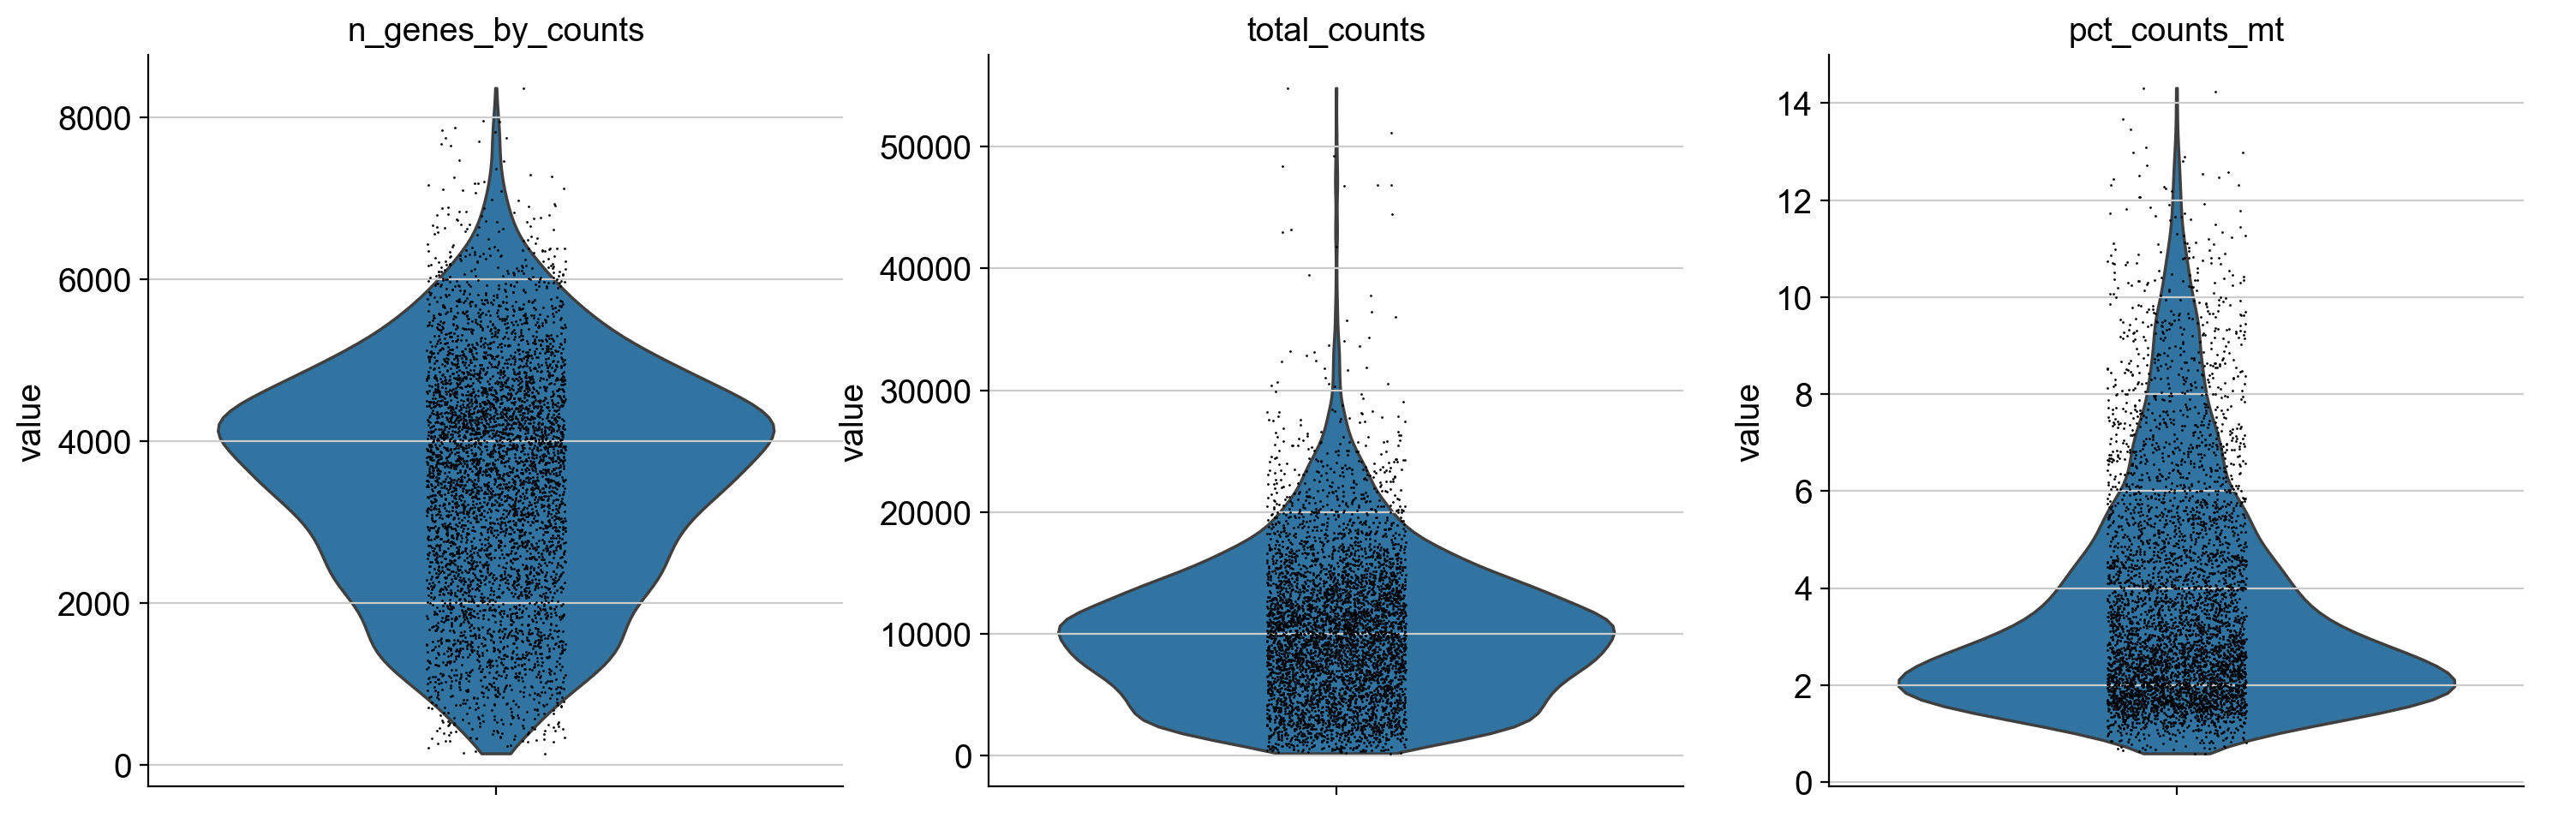

In [30]:
add_qc_metrics(adata)
plot_qc_violin(adata, keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"], show=True)


In [31]:
adata = filter_cells_and_genes(
    adata,
    # min_genes  : スポットあたりの検出遺伝子数の下限 / min detected genes per spot
    # min_cells  : その遺伝子が検出されるスポット数の下限 / min spots in which a gene is detected
    min_genes = cfg["qc"]["min_genes_per_spot"],
    min_cells = cfg["qc"]["min_cells"],
    pct_counts_mt_max = cfg["qc"]["pct_counts_mt_max"],
)
print(adata)


filtered out 52 cells that have less than 500 genes expressed
filtered out 16376 genes that are detected in less than 5 cells
AnnData object with n_obs × n_vars = 4825 × 20225
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


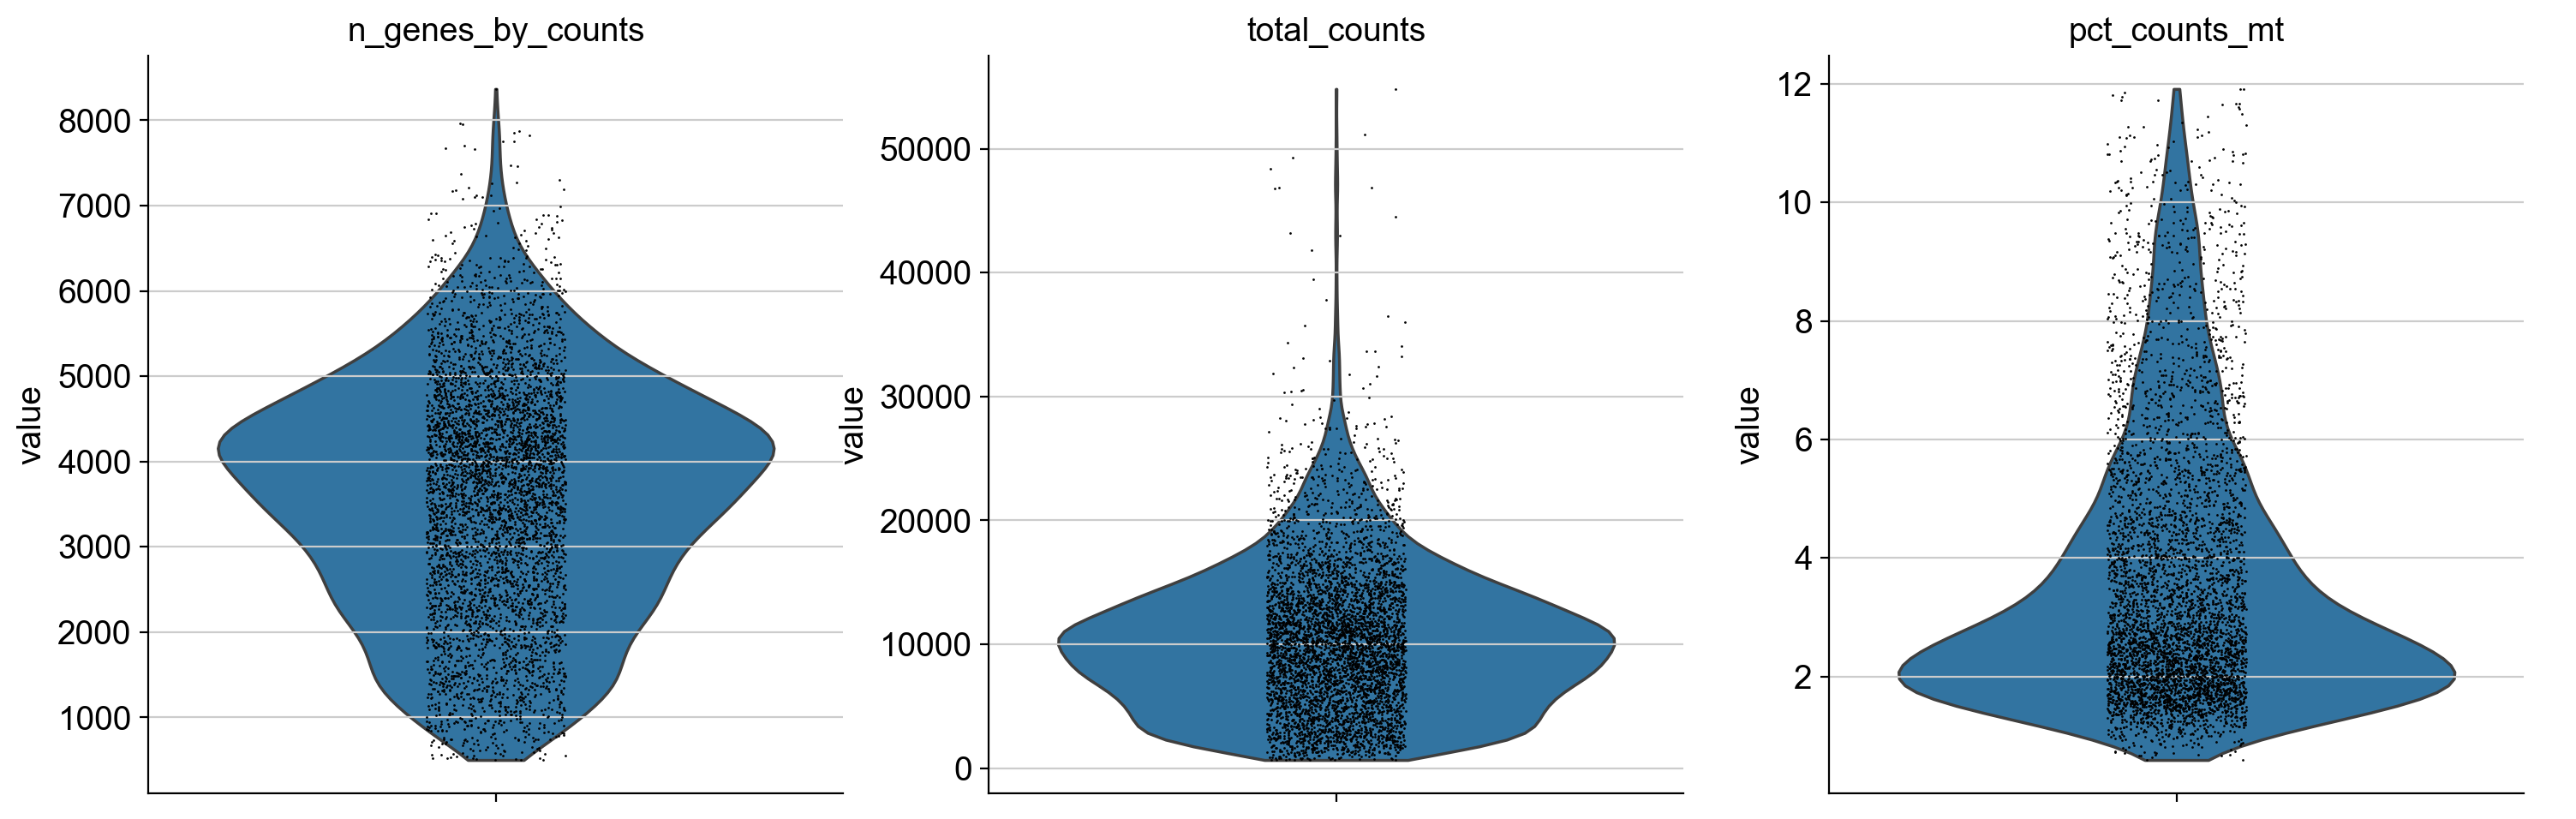

In [32]:
plot_qc_violin(adata, keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"], show=True)


### QC の所見 / QC Findings

`scripts/run_qc.py` による実行結果。図は `results/qc/` に出力される。

| | spots | genes |
| --- | ---: | ---: |
| フィルタ前 / before | 4,898 | 36,601 |
| フィルタ後 / after | 4,825 | 20,225 |

- スポットは 73 個（1.5%）、遺伝子は 16,376 個（45%）を除去した。遺伝子側の減りが大きいのは `min_cells=5` により**どのスポットでもほとんど検出されない遺伝子**を落とした結果で、Visium では標準的な挙動である。
- 中央値は `n_genes_by_counts` 3,654 → 3,681、`pct_counts_mt` 2.89% → 2.86% とほぼ変わらない。**全体を削ったのではなく裾だけを削れている。**

**閾値の調整は不要と判断した。** 空間分布（`qc_spatial.png`）に技術的アーティファクトのパターン — 組織の端だけが極端に低い（tissue edge effect）、帯状・筋状の抜け、区画単位のまとまった低下 — が見られず、counts の高低が組織構造と対応している。したがって値の低さは技術的失敗ではなく生物学的な差に由来すると解釈できる。

Space Ranger の出力（`data/raw/Others/Visium_Human_Breast_Cancer_metrics_summary.csv`）とも一致しており、読み込みと QC 計算が 10x の公式パイプラインを再現できている裏付けになる。

| 項目 | Space Ranger | この notebook |
| --- | ---: | ---: |
| Number of Spots Under Tissue | 4,898 | 4,898 |
| Median UMI Counts per Spot | 9,720.5 | 9,720.5 |
| Median Genes per Spot | 3,654 | 3,654 |

Sequencing Saturation は 72.1% で、10x が推奨深度を定める際の設計目標（>50%）を上回る。深度が十分なため、**検出遺伝子数が低い領域は「読めなかったから低い」のではなく、実際に細胞密度や転写活性が低い**と解釈できる。なお `n_genes_by_counts` は深度と強く相関するため、この値の高低から細胞種を同定することはできない。確認には第5章以降のクラスタリングとマーカー遺伝子が必要である。

---

Results from `scripts/run_qc.py`; figures are written to `results/qc/`.

Filtering removed 73 spots (1.5%) and 16,376 genes (45%). The large drop on the gene side comes from `min_cells=5` discarding genes detected in almost no spots, which is standard for Visium. Medians barely move (`n_genes_by_counts` 3,654 → 3,681), i.e. only the tails were trimmed.

**No threshold adjustment was needed.** The spatial plot shows none of the usual technical artifacts (tissue edge effects, banding, block-wise dropouts), and counts track tissue structure, so low values reflect biology rather than technical failure. The metrics also match Space Ranger's own summary, confirming that loading and QC reproduce the official pipeline. Sequencing saturation is 72.1%, above the >50% target 10x uses to set recommended depth — so low gene counts are not a depth artifact. Note that `n_genes_by_counts` correlates strongly with depth, so it cannot be used to identify cell types; that requires the clustering and marker genes in later sections.


## 4. 正規化とログ変換 / Normalization and Log Transformation

スポット間の捕捉効率の差を揃え、対数変換したうえで高変動遺伝子（HVG）を選ぶ。

- **正規化** … `normalize_total(target_sum)` で各スポットの合計カウントを揃える。補正しなければ、発現量の差が生物学的な差ではなく深度の差に引きずられる
- **対数変換** … `log1p` で分布の歪みを抑える。少数の高発現遺伝子が距離計算を支配しないようにする
- **HVG 選択** … 情報量の乏しい遺伝子を落とし、後続の次元削減でのノイズを減らす

`normalize_and_hvg()` はこの3つをまとめて実行し、HVG で subset したものを返す。subset 前の全遺伝子は `adata.raw` に保存されるので、マーカー遺伝子解析ではそちらを使う。

Equalize per-spot capture efficiency, log-transform, then select highly variable genes (HVGs).
`normalize_and_hvg()` performs all three and returns the HVG-subset data; the full gene set before subsetting is kept in `adata.raw` for marker gene analysis.


In [ ]:
adata = normalize_and_hvg(
    adata,
    target_sum=cfg["normalization"]["target_sum"],
    n_top_genes=cfg["feature_selection"]["n_top_genes"],
)
print(adata)


### 正規化・HVG 選択の所見 / Normalization and HVG Findings

`scripts/run_preprocess.py` による実行結果。図は `results/preprocess/` に出力される。

| | spots | genes |
| --- | ---: | ---: |
| 入力（QC 済み） | 4,825 | 20,225 |
| 正規化・HVG 選択後 | 4,825 | 2,000 |

**確認したこと**

1. **深度差が実際に揃った。** 正規化前のスポット合計カウントは 663〜54,822 で **83倍の開き**があった。`normalize_total(target_sum=10000)` 後は全スポットが 10,000 に一致する（`normalization_effect.png`）。この図は対数軸のストリッププロットで描いている。正規化後は値の範囲がゼロになりヒストグラムのビンが作れないため
2. **HVG は 20,225 遺伝子から 2,000 を選択。** `hvg_selection.png` で、分散が期待値より大きい遺伝子（黒）が選ばれていることを確認した
3. **`adata.raw` に 20,225 遺伝子が保持されている。** subset 後も全遺伝子にアクセスできる

---

Results from `scripts/run_preprocess.py`; figures are written to `results/preprocess/`.

Per-spot totals spanned 663–54,822 (an 83-fold spread) before normalization and are identical at 10,000 afterwards. HVG selection kept 2,000 of 20,225 genes, with the full set retained in `adata.raw`.


## 5. スケールと PCA・クラスタリング / Scaling, PCA, and Clustering


In [ ]:
# スケール・PCA・近傍グラフ・UMAP は run_dimensionality_reduction() が行う
# Scaling, PCA, neighbor graph and UMAP are handled by run_dimensionality_reduction()
dr = cfg["dimension_reduction"]
seed = cfg["project"]["random_seed"]

adata = run_dimensionality_reduction(
    adata,
    DimReduceParams(
        pca_n_components=dr["pca_n_components"],
        neighbors_k=dr["neighbors_k"],
        umap_min_dist=dr["umap_min_dist"],
        random_state=seed,
    ),
)
sc.pl.pca_variance_ratio(adata, n_pcs=20)


In [ ]:
cl = cfg["clustering"]

adata = run_clustering(
    adata,
    ClusteringParams(
        method=cl["method"],
        resolution=cl["resolution"],
        key_added="clusters",
        random_state=seed,
    ),
)
print(adata.obs["clusters"].value_counts().sort_index())


### クラスタリングと空間ドメインの所見 / Clustering Findings

`scripts/run_clustering.py` による実行結果。図と CSV は `results/clustering/` に出力される。

**resolution の選定**

近傍グラフは共通なので Leiden を回し直して比較した。

| resolution | クラスタ数 | 最小クラスタ | 50 spots 未満のクラスタ |
| ---: | ---: | ---: | ---: |
| 0.5 | 7 | 92 spots | 0 |
| 0.8 | 12 | 93 spots | 0 |
| **1.0** | **14** | **93 spots** | **0** |
| 1.5 | 16 | 100 spots | 0 |

どの値でも 50 spots 未満の断片的なクラスタは生じない。**既定の 1.0（14クラスタ）を採用した。** 最小クラスタが 93 spots あり細分化しすぎておらず、空間プロットで各クラスタがまとまった領域を形成しているため。より粗い領域分けを見たい場合は 0.5（7クラスタ）が選択肢になる。

**確認したこと**

1. **クラスタが空間的にまとまった領域を形成する**（`spatial_clusters.png`）。散らばったノイズではなく、組織構造に対応した空間ドメインが得られている。発現プロファイルだけでクラスタリングしており空間座標は使っていないので、これは**データ側にある空間構造が再現された**ことを意味する
2. **UMAP 上でもクラスタが分離している**（`umap_clusters.png`）。クラスタ 0・1 が他から離れ、残りは連続的な構造を持つ
3. **Moran's I 上位が解釈可能な遺伝子で占められている**

| 遺伝子 | Moran's I | 想定される意味 |
| --- | ---: | --- |
| `ISG15` | 0.583 | インターフェロン応答 |
| `C1QA` / `C1QB` / `C1QC` | 0.53 / 0.51 / 0.35 | 補体。マクロファージのマーカー |
| `CD52` / `LAPTM5` | 0.40 / 0.26 | リンパ球系 |
| `COL11A1` | 0.300 | コラーゲン。がん関連線維芽細胞 |
| `HSPG2` | 0.223 | 基底膜 |

いずれも FDR 補正後の p 値が 0 で、空間的に構造を持つ遺伝子が免疫系と間質系で占められる。乳がん組織として筋の通った結果である。

**残る課題**

**クラスタの正体（腫瘍巣・間質・免疫浸潤など）の同定には至っていない。** これにはクラスタごとのマーカー遺伝子が必要で、`src/deg.py` の `compute_markers()` が用意されているが対応する Issue がない。別途立てること。

QC の段階で `n_genes_by_counts` が高かった領域（`results/qc/qc_spatial.png`）がどのクラスタに対応するかを重ねて見ると、QC での推測の答え合わせになる。

---

Results from `scripts/run_clustering.py`; figures and CSVs are written to `results/clustering/`.

A resolution sweep (0.5 / 0.8 / 1.0 / 1.5) produced no fragmented clusters at any value; `resolution=1.0` with 14 clusters was adopted since the smallest cluster still holds 93 spots and each cluster forms a contiguous region in the spatial plot. Clustering used expression only — no spatial coordinates — so the spatial coherence reflects structure genuinely present in the data. The top genes by Moran's I are immune (interferon response, complement/macrophage, lymphocyte) and stromal (collagen, basement membrane), all with FDR-corrected p ≈ 0.

Identifying what each cluster actually is still requires marker genes, deferred to a follow-up issue.


## 6. 空間・UMAP 可視化 / Spatial and UMAP Visualization


In [ ]:
# 発現空間（UMAP）と組織上の配置（spatial）を並べて見る
# Compare expression space (UMAP) with the arrangement in tissue (spatial)
plot_umap(adata, color="clusters", show=True)
plot_spatial(adata, color="clusters")


## 7. 遺伝子発現の空間プロット / Spatial Plots of Gene Expression


In [ ]:
genes = adata.var_names[:4].tolist()  # または ['GENE1', 'GENE2', ...]
plot_spatial(adata, color=genes)


## 8. Squidpy: 空間隣接とモランI / Squidpy: Spatial Neighbors and Moran's I


In [ ]:
build_spatial_neighbors(adata, coord_type="generic", delaunay=True)
run_moran_i(adata, n_genes=100)

adata.uns["moranI"].sort_values("I", ascending=False).head(10)


## 9. 結果の保存 / Saving Results


In [ ]:
out_dir = paths["data_processed"]
out_dir.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(out_dir / f"{cfg['inputs']['sample_id']}_clustered.h5ad")
